# s2ISM Workflow


### This Notebook's Operations

This workflow starts from `FILENAME_INPUT`, creates a calibrated source file, then appends only the s2ISM reconstruction into the same output file.

1. `FILENAME_INPUT` -> calibration -> `FILENAME_OUTPUT`
2. `FILENAME_OUTPUT` -> `s2ism_001` with `mode="append"` -> `FILENAME_OUTPUT`

The exported file contains the s2ISM output under `/output`. The default output key is the reconstructed s2ISM decay at `/output/{run_id}/products/s2ism`; the derived intensity preview remains at `/output/{run_id}/products/s2ism_intensity`.

This `_only` notebook intentionally does not write phasor maps, fitted lifetimes, fit parameters, or lifetime summary products into the output HDF5 file. The saved HDF5 file therefore contains calibration metadata plus the current s2ISM operation result only.

### Workflow overview

1. **Calibration** - Correct per-channel timing offsets (channel skew) and instrument response using a reference dye.
2. **Data loading** - Read the calibrated data and auxiliary traces from the HDF5 file.
3. **IRF inspection & smoothing** - Visualise and optionally smooth the per-channel Impulse Response Functions.
4. **Spatial PSF simulation** - Simulate the expected spatial point-spread functions for the SPAD array geometry.
5. **s2ISM reconstruction** - Deconvolve the 4D `(y, x, time, channel)` dataset using the spatial-only kernel and save only this reconstruction.

### Required packages

| Package | Role |
|---|---|
| `brighteyes_ism` | PSF simulation, ISM graph utilities, MCS I/O |
| `brighteyes_mcs_dataprep` | HDF5 calibration, data preparation and output writing |
| `s2ism` | s2ISM reconstruction engine and PSF estimator |
| `numpy`, `matplotlib` | Numerics and plotting |
| `h5py` | Low-level HDF5 access |
| `torch` | GPU-accelerated tensor operations (used for IRF smoothing) |


In [1]:
# ── File paths ────────────────────────────────────────────────────────────
FILE_REFERENCE = '/mnt/DATA/Mixed Data/NEW/FlimsLab_2ns5/pixel_dwell_1_us.h5'
FILENAME_INPUT = '/mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis.h5'

DATA_KEY = "data" # usual input key: ('data', 'data_channels_extra')


# ── Calibration parameters ─────────────────────────────────────────────────
REFERENCE_TYPE = "ref" #or "irf"
TAU_REF = 2.5
FIT_MODE             = "model_shift"
FIT_TYPE             = "likelihood"
LASER_FREQ_MHZ       = None
LASER_PERIOD_NS      = None
CHANNEL_SKEW_SOURCE  = "ref"
OVERWRITE            = True

# ── s2ISM output parameters ────────────────────────────────────────────────
THRESHOLD = 0.05  # Used only for display/preview cells, not written as lifetime data.

# The _only notebook writes the current operation only and uses the requested suffix.
FILENAME_OUTPUT = FILENAME_INPUT.replace(".h5", "_s2ism.h5")

print(f"Input file (ref): {FILE_REFERENCE}")
print(f"Input file (data): {FILENAME_INPUT}")
print(f"Calibration and output products to: {FILENAME_OUTPUT}")


Input file (ref): /mnt/DATA/Mixed Data/NEW/FlimsLab_2ns5/pixel_dwell_1_us.h5
Input file (data): /mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis.h5
Calibration and output products to: /mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis_s2ism.h5


## Imports

In [2]:
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py

from tqdm import trange, tqdm
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift

import brighteyes_ism.simulation.PSF_sim as sim
import brighteyes_ism.analysis.Graph_lib as gra
from brighteyes_mcs_reader import reader_legacy

import brighteyes_flism.graph_tools as graph
graph = importlib.reload(graph)

import brighteyes_mcs_dataprep.alignment as alignment_module
alignment_module = importlib.reload(alignment_module)

from brighteyes_mcs_dataprep.alignment import Alignment
from brighteyes_mcs_dataprep import (
    H5OutputProduct,
    calibrate_h5_file,
    show_h5_structure_html,
    sum_channel_applying_shifts,
    write_h5_output_run,
)

from s2ism import s2ism as s2
import s2ism.psf_estimator as est


In [3]:
# Derived HDF5 schema keys. Do not edit unless the schema changes.
DATA_KEY_TO_CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]
CALIBRATION_PRODUCT = DATA_KEY_TO_CALIBRATION_PRODUCT[INSPECT_DATA_KEY]


## Calibration

`calibrate_h5_file` processes the raw HDF5 data file and writes a calibrated copy containing:

- **Channel skew** – Per-channel temporal offsets estimated via phase cross-correlation, stored as integer bin shifts.
- **IRF traces** – Aligned per-channel Impulse Response Functions.
- **Reference traces** – Aligned per-channel reference-dye decay curves.
- **Laser timing** – Repetition frequency and period, either read from metadata or fitted.

> **Note:** `channel_skew_fit_reference_channel=12` uses the central SPAD pixel as the timing reference. `channel_skew_fit_upsampling=10` enables sub-bin precision.


In [4]:
calibrate_h5_file(
    FILENAME_INPUT,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    output_path=FILENAME_OUTPUT,
    overwrite=OVERWRITE,
)


Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

'/mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis_s2ism.h5'

## Load Calibrated Data

**Loaded quantities**
- `laser_freq_mhz`, `laser_period_ns` – Laser timing stored by the calibration step.
- `nbin` – Number of TCSPC time bins per laser period.
- `pixel_size_x_um` – Lateral pixel size in micrometres.
- `pxdwelltime` – Pixel dwell time in microseconds.
- `data_input` – Raw photon count array, shape `(rep, z, y, x, t_bins, channels)`.
- `channel_skew` – Per-channel timing offsets in bins.
- `irf_common_delay_realigned` – Per-channel IRF traces after realignment, shape `(t_bins, channels)`.
- `ref_common_delay_realigned` – Per-channel reference-dye decay traces after realignment.

`dset` (shape `(y, x, t_bins, channels)`) is the squeezed version of `data_input`, used as input to s²ISM.


In [5]:
with h5py.File(FILENAME_OUTPUT, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata    = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                 = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew               = calibration["timing/channel_skew_bins"][:]
    irf_common_delay_realigned = calibration["aligned/irf_trace"][:]
    irf_from_fit               = calibration["fit/irf_trace"][:]
    ref_common_delay_realigned = calibration["aligned/reference_trace"][:]

dset = np.squeeze(data_input)  # (y, x, t_bins, channels)

print(f"Laser timing : {laser_freq_mhz:.4f} MHz  ({laser_period_ns:.4f} ns period)")
print(f"data_input   : {data_input.shape}  (rep, z, y, x, t_bins, channels)")


Laser timing : 40.0000 MHz  (25.0000 ns period)
data_input   : (1, 1, 801, 801, 91, 25)  (rep, z, y, x, t_bins, channels)


### Inspect HDF5 structure (optional)

In [6]:
# show_h5_structure_html(FILENAME_OUTPUT)


## Channel Summation with Timing Correction

The 25 SPAD channels have small per-channel temporal offsets (*channel skew*).
`sum_channel_applying_shifts` corrects these before summing channels.

This gives a conventional CLSM-like decay trace (`data_summed`) and summed IRF/reference traces
that are useful for checking calibration and comparing temporal profiles. These helper arrays are
not written into the s2ISM-only output file.


In [7]:
if False:
    irf_common_delay_realigned = Alignment.clean_irf_stack(
        irf_common_delay_realigned,
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed  = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())
ref_summed  = sum_channel_applying_shifts(ref_common_delay_realigned, channel_skew, axis=())

print("data_summed :", data_summed.shape)
print("irf_summed  :", irf_summed.shape)
print("ref_summed  :", ref_summed.shape)


Summing shifted histogram chunks:   0%|          | 0/44 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

data_summed : (801, 801, 91)
irf_summed  : (91,)
ref_summed  : (91,)


## Time Axis

Compute the physical time axis (ns) corresponding to the TCSPC bins.
The bin width `dt` is the laser period divided by the number of bins.
The same `t` axis is written with the s2ISM output product.


In [8]:
dt = laser_period_ns / nbin   # bin width [ns]
t  = np.arange(nbin, dtype=float) * dt   # time axis [ns]

print(f"Excitation frequency : {laser_freq_mhz:.2f} MHz")
print(f"Bin width            : {dt:.4f} ns")
print(f"Time axis (ns)       : {t[0]:.3f} … {t[-1]:.3f}  ({nbin} bins)")


Excitation frequency : 40.00 MHz
Bin width            : 0.2747 ns
Time axis (ns)       : 0.000 … 24.725  (91 bins)


## IRF Smoothing Utilities

These helper functions implement a **median filter** along arbitrary tensor dimensions using PyTorch.
A median filter preserves the sharp IRF rising edge while removing isolated noisy bins.


In [9]:
import torch

def pad_tensor(x: torch.Tensor, pad_left: int, pad_right: int, dim: int, mode: str = "reflect"):
    """
    Pad a tensor along one dimension.

    Args:
        x         : Input tensor to pad.
        pad_left  : Number of elements to pad before the data along the specified dimension.
        pad_right : Number of elements to pad after the data along the specified dimension.
        dim       : Dimension along which to pad.
        mode      : Padding mode — one of {"reflect", "replicate", "constant"}.

    Returns:
        Padded tensor with the same dtype and device as input.
    """
    if pad_left == 0 and pad_right == 0:
        return x

    length = x.shape[dim]

    if mode == "reflect":
        left_idx  = torch.arange(pad_left, 0, -1, device=x.device)
        right_idx = torch.arange(length - 2, length - pad_right - 2, -1, device=x.device)
    elif mode == "replicate":
        left_idx  = torch.zeros(pad_left, dtype=torch.long, device=x.device)
        right_idx = torch.full((pad_right,), length - 1, dtype=torch.long, device=x.device)
    elif mode == "constant":
        pad_shape      = list(x.shape)
        pad_shape[dim] = pad_left + pad_right
        constant_pad   = torch.zeros(pad_shape, dtype=x.dtype, device=x.device)
        return torch.cat(
            [constant_pad.narrow(dim, 0, pad_left), x, constant_pad.narrow(dim, pad_left, pad_right)],
            dim=dim,
        )
    else:
        raise ValueError(f"Unsupported padding mode: {mode}")

    pad_left_tensor  = x.index_select(dim, left_idx)
    pad_right_tensor = x.index_select(dim, right_idx)
    return torch.cat([pad_left_tensor, x, pad_right_tensor], dim=dim)


def median_filter(x: torch.Tensor, window_size=3, dims=None, mode="reflect"):
    """
    Apply an N-dimensional median filter over user-specified dimensions.

    Args:
        x           : Input tensor of any shape.
        window_size : Window size(s) — int for all dims, or list matching len(dims).
        dims        : Dimensions to filter along. None filters all dimensions.
        mode        : Padding mode — one of {"reflect", "replicate", "constant"}.

    Returns:
        Median-filtered tensor of the same shape as x.
    """
    if dims is None:
        dims = list(range(x.ndim))

    if isinstance(window_size, int):
        window_size = [window_size] * len(dims)
    elif len(window_size) != len(dims):
        raise ValueError("window_size must be scalar or match len(dims)")

    for w in window_size:
        if w % 2 == 0:
            raise ValueError(f"All window sizes must be odd, got {w}")

    out = x
    for d, w in zip(dims, window_size):
        pad_left  = (w - 1) // 2
        pad_right = w // 2
        out = pad_tensor(out, pad_left, pad_right, d, mode=mode)
        out = out.unfold(d, w, 1).median(dim=-1).values

    return out


In [10]:
irf_common_delay_realigned_smoothed = median_filter(
    torch.tensor(irf_common_delay_realigned), window_size=5, dims=[0], mode="replicate"
)


### Visualise per-channel IRFs

Each panel shows the normalised IRF traces for all 25 SPAD channels, stacked vertically.
Comparing raw (left) and smoothed (right) helps assess whether smoothing is necessary.


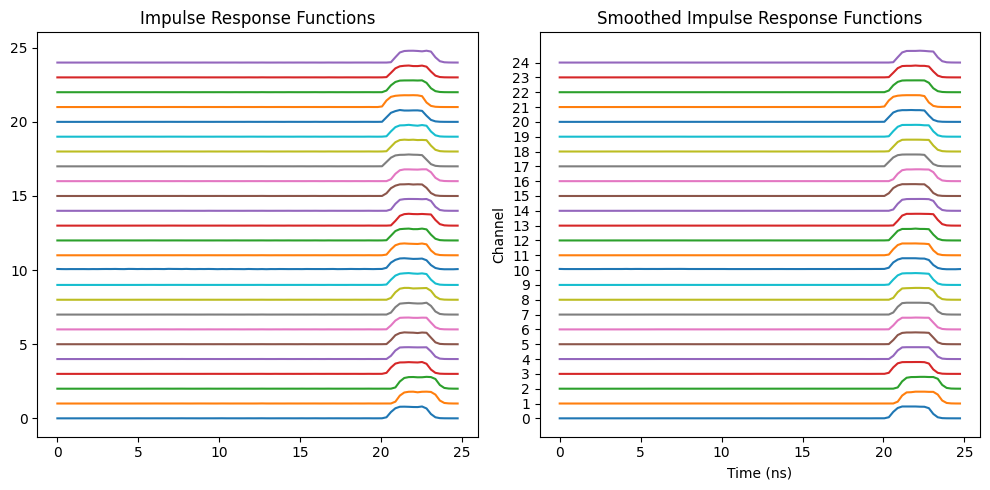

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for n in range(dset.shape[-1]):
    irf_n          = irf_common_delay_realigned[:, n]
    irf_norm       = irf_n / (irf_n.max() + 1e-10)

    irf_n_smoothed      = irf_common_delay_realigned_smoothed[:, n]
    irf_norm_smoothed   = irf_n_smoothed / (irf_n_smoothed.max() + 1e-10)

    ax[0].plot(t, 0.8 * irf_norm + n)
    ax[1].plot(t, 0.8 * irf_norm_smoothed + n)

ax[0].set_title("Impulse Response Functions")
ax[1].set_title("Smoothed Impulse Response Functions")
plt.yticks(np.arange(25))
plt.xlabel("Time (ns)")
plt.ylabel("Channel")
plt.tight_layout()


# s2ISM Image Reconstruction

This section reconstructs the calibrated SPAD data with **s2ISM**, a deconvolution-based ISM method that jointly processes all SPAD channels.

The reconstruction operates on the full 4D dataset `dset` with shape `(y, x, t_bins, channels)` and produces `s2_flism` with shape `(y, x, t_bins)`.


## Spatial PSF Simulation

The s²ISM reconstruction requires the **Point Spread Functions (PSFs)** for each SPAD pixel,
encoding the excitation/emission optical transfer functions and the detector array geometry.

**Key parameters to adjust for your system:**
- `na` – Objective numerical aperture
- `exPar.wl` / `emPar.wl` – Excitation and emission wavelengths [nm]
- `n` – Refractive index of the immersion medium
- `grid.pxsizex` – Lateral pixel size [nm] (read from metadata)
- `grid.pxpitch` / `grid.pxdim` – SPAD pixel pitch and size [nm]
- `grid.N` – SPAD pixels per side (5 for the 5×5 array)


In [12]:
exPar = sim.simSettings()
exPar.na         = 1.4    # numerical aperture
exPar.wl         = 488    # excitation wavelength [nm]
exPar.gamma      = 45     # polarisation parameter
exPar.beta       = 90     # polarisation parameter
exPar.n          = 1.5    # refractive index
exPar.mask_sampl = 100    # pupil plane sample points

emPar    = exPar.copy()
emPar.wl = 500            # emission wavelength [nm]

grid           = sim.GridParameters()
grid.Nz        = 2
grid.pxsizex   = pixel_size_x_um * 1e3   # pixel size [nm]
grid.pxsizez   = 720                      # axial spacing [nm]
grid.pxpitch   = 75e3                     # detector array pitch [nm]
grid.pxdim     = 50e3                     # detector pixel size [nm]
grid.N         = 5                        # pixels per axis

psf_spatial, _, _ = est.psf_estimator_from_data(
    dset.sum(-2), exPar, emPar, grid, z_out_of_focus=grid.pxsizez
)


pxsizex       50.00
pxsizez       720.00
Nx            100.00
Nz            2.00
pxpitch       75000.00
pxdim         50000.00
pinhole_shape square
geometry      rect
N             5.00
M             520.00
rotation      3.15
mirroring     1.00
name          
shift         67.00


### Visualise the simulated PSFs

Out-of-focus PSFs


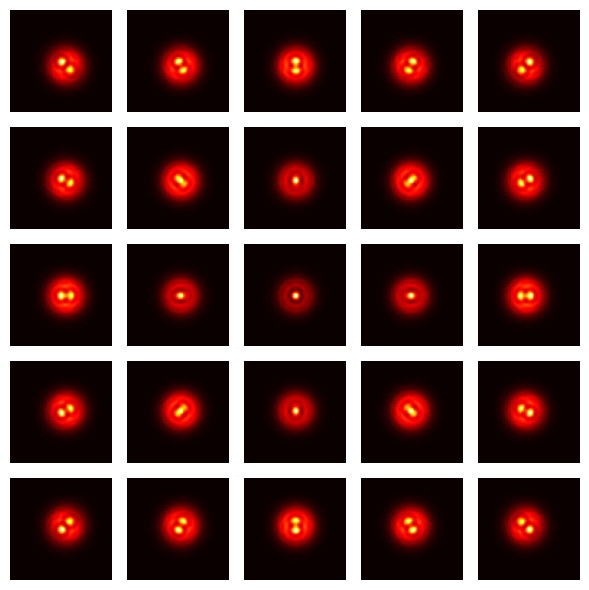

In [13]:
print("Out-of-focus PSFs")
fig_1 = gra.ShowDataset(psf_spatial[0])


In-focus PSFs


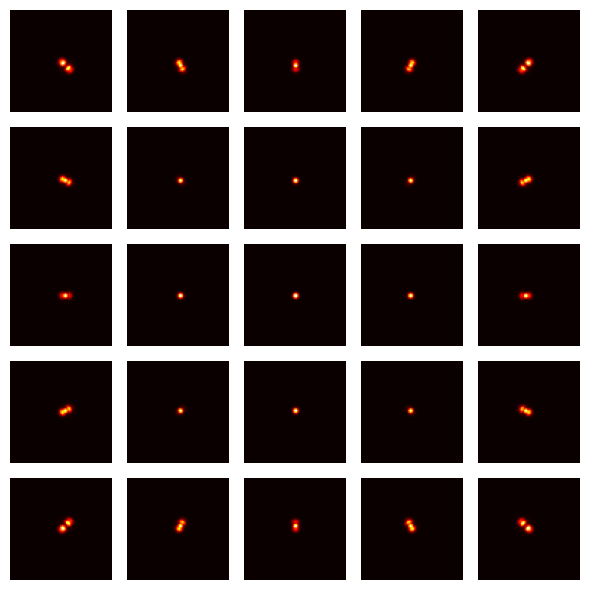

In [14]:
print("In-focus PSFs")
fig_2 = gra.ShowDataset(psf_spatial[1])


## Build the Spatio-Temporal Deconvolution Kernels

`est.combine_psf_irf` forms the outer product of the spatial PSF and the per-channel IRF,
producing a kernel of shape `(Nz, channels, t_bins, y_psf, x_psf)`.

Three kernels are built for inspection and experimentation, but the `_only` export below uses
`psf_delta` so the saved result is the spatial s2ISM reconstruction with the measured decay axis still present.

| Kernel | IRF used | When to use |
|---|---|---|
| `psf_irf` | Measured IRF | Full spatio-temporal deconvolution: removes both spatial blur and IRF broadening. |
| `psf_irf_smoothed` | Smoothed IRF | Same as above, but more robust when the raw IRF is noisy. |
| `psf_delta` | Delta function at bin `nbin//2` | Spatial deconvolution only: removes spatial blur from each time bin and leaves the decay broadening in the data. |

The default `_only` workflow uses `psf_delta` in the reconstruction cell below.


In [15]:
# Kernel 1: full spatio-temporal kernel with the measured IRF
psf_irf = est.combine_psf_irf(psf_spatial, irf_common_delay_realigned)


In [16]:
# Kernel 2: full spatio-temporal kernel with the smoothed IRF
psf_irf_smoothed = est.combine_psf_irf(psf_spatial, irf_common_delay_realigned_smoothed)


In [17]:
# Kernel 3: spatial-only kernel — the IRF is replaced by a delta function centred at nbin//2.
delta_irf = np.zeros_like(irf_common_delay_realigned)
delta_irf[nbin // 2, :] = 1

psf_delta = est.combine_psf_irf(psf_spatial, delta_irf)

print("psf_delta shape:", psf_delta.shape,
      "  (Nz, channels, t_bins, y_psf, x_psf)")

psf_delta shape: (2, 71, 71, 91, 25)   (Nz, channels, t_bins, y_psf, x_psf)


## s²ISM Reconstruction

`s2.batch_reconstruction` applies Richardson-Lucy deconvolution with the chosen kernel.
The image is processed in overlapping spatial tiles to manage memory.

`batch_reconstruction` with `psf_delta` removes the spatial PSF from each time bin
independently. The output `s2_flism` (shape `(y, x, t_bins)`) contains the spatially
deconvolved decay traces with the IRF broadening still present.


**Parameters to adjust:**
- `batch_size` – Spatial tile size `[rows, cols]`. Reduce if you run out of memory.
- `overlap` – Tile overlap in pixels. Must exceed the PSF support to avoid stitching artefacts.
- `max_iter` – Richardson-Lucy iterations. More iterations sharpen the result but amplify noise.
- `process` – `'gpu'` (recommended if CUDA is available) or `'cpu'`.

The reconstruction returns a list; index `[1]` selects the in-focus plane, shape `(y, x, t_bins)`.


In [19]:
# Spatial s2ISM reconstruction: the spatial PSF is removed from each time bin.
# The IRF is intentionally not deconvolved in this _only workflow.
s2_rec = s2.batch_reconstruction(
    dset, psf_delta, batch_size=[201, 201], overlap=40, max_iter=5, process="gpu"
)
s2_flism = s2_rec[1]   # in-focus plane, shape: (y, x, t_bins)

print("s2_flism shape:", s2_flism.shape, "  (y, x, t_bins)")


Batch 1/25


Progress: 6it [00:22,  3.73s/it]                       


Batch 2/25


Progress: 6it [00:19,  3.26s/it]                       


Batch 3/25


...

Batch 24/25


Progress: 6it [00:14,  2.39s/it]                       


Batch 25/25


Progress: 6it [00:10,  1.81s/it]                       


s2_flism shape: (801, 801, 91)   (y, x, t_bins)


### Intensity Map

Sum the reconstructed decay traces over the time axis to produce a conventional intensity image.


Text(0.5, 1.0, 's$^2$ISM intensity')

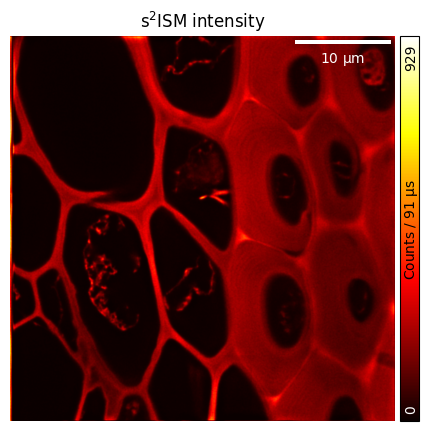

In [20]:
intensity_map = s2_flism.sum(-1)

fig, ax = plt.subplots(figsize=(15, 5))
gra.ShowImg(intensity_map, pixel_size_x_um, pxdwelltime, fig=fig, ax=ax)
ax.set_title(r"s$^2$ISM intensity")


### Temporal Trace Comparison

Compare the spatially integrated decay of the central SPAD channel before and after
reconstruction, alongside the IRF.
The reconstructed trace should not be broader than the raw data; the IRF peak
should still be visible (IRF was *not* deconvolved).


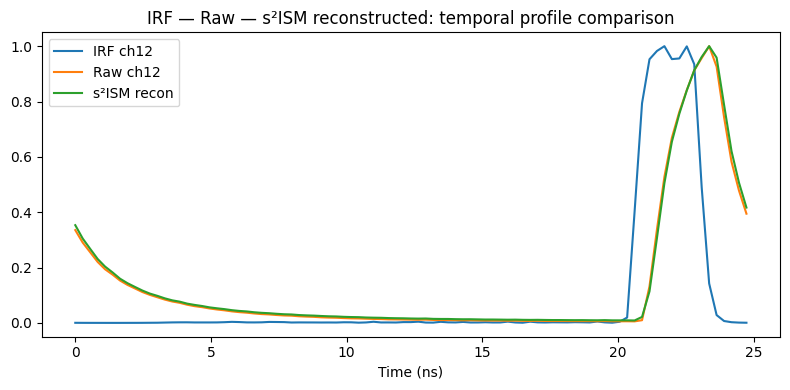

In [21]:
ch = 12   # SPAD channel to inspect (12 = central pixel of the 5×5 array)

irf_ch   = irf_common_delay_realigned[:, ch]
raw_ch   = dset[:, :, :, ch].sum(axis=(0, 1))   # sum over x, y
recon_ch = s2_flism.sum(axis=(0, 1))             # s2_flism has no channel axis

def norm(x):
    return x / x.max()

plt.figure(figsize=(8, 4))
plt.plot(t, norm(irf_ch),   label="IRF ch12")
plt.plot(t, norm(raw_ch),   label="Raw ch12")
plt.plot(t, norm(recon_ch), label=r"s²ISM recon")
plt.xlabel("Time (ns)")
plt.legend()
plt.title(r"IRF — Raw — s²ISM reconstructed: temporal profile comparison")
plt.tight_layout()


## s2ISM-only Export

Save only the current s2ISM operation into the HDF5 output file. No phasor products, fitted lifetime maps, fit parameters, or lifetime summaries are written by this `_only` notebook.

The default HDF5 output product is `/output/{run_id}/products/s2ism`, which stores the reconstructed decay stack with axes `y,x,time_bin`.


In [25]:
if FILENAME_OUTPUT is not None:
    s2ism_common_attrs = {
        "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
        "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
        "source_metadata_path": "/raw/metadata",
        "source_axes_path": "/raw/axes",
        "time_axis_source": "/raw/axes/digital_time_ns",
        "time_bin_ns": laser_period_ns / nbin,
        "laser_frequency_mhz": laser_freq_mhz,
        "laser_period_ns": laser_period_ns,
    }
    s2ism_intensity = s2_flism.sum(axis=-1)
    target_path, output_run_id = write_h5_output_run(
        FILENAME_OUTPUT,
        "s2ism_001",
        [
            H5OutputProduct(
                "s2ism",
                s2_flism,
                attrs={
                    **s2ism_common_attrs,
                    "data_role": "s2ism_reconstructed_decay",
                    "axis_order": "y,x,time_bin",
                },
            ),
            H5OutputProduct(
                "s2ism_intensity",
                s2ism_intensity,
                attrs={
                    **s2ism_common_attrs,
                    "data_role": "s2ism_integrated_intensity",
                    "axis_order": "y,x",
                    "source_data_path": "/output/{run_id}/products/s2ism",
                },
            ),
        ],
        mode="append",
        output_path=None,
        output_key_overwrite=True,
        output_type="image_tool",
        tool_name="s2ISM reconstruction",
        algorithm_name="s2.batch_reconstruction",
        parameters={
            "kernel": "psf_delta",
            "batch_size": [301, 301],
            "overlap": 40,
            "max_iter": 5,
            "process": "gpu",
            "data_key": DATA_KEY,
            "calibration_product": CALIBRATION_PRODUCT,
        },
        metadata={
            **s2ism_common_attrs,
            "pixel_size_x_um": pixel_size_x_um,
            "pixel_dwell_time_us": pxdwelltime,
            "output_ny": s2_flism.shape[0],
            "output_nx": s2_flism.shape[1],
            "output_time_bins": s2_flism.shape[-1],
            "s2ism_intensity_path": "/output/{run_id}/products/s2ism_intensity",
            "selected_channel_count": data_input.shape[-1],
            "channel_aggregation": "s2ism",
        },
        axes=[
            H5OutputProduct("time_ns", t, attrs={"axis": "time_bin", "long_name": "time", "units": "ns"}),
            H5OutputProduct("x_um", np.linspace(-pixel_size_x_um * (s2_flism.shape[1] - 1) / 2, pixel_size_x_um * (s2_flism.shape[1] - 1) / 2, s2_flism.shape[1]) if s2_flism.shape[1] > 1 else np.asarray([0.0]), attrs={"axis": "x", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "x position", "offset_um": 0.0, "pixel_size_um": pixel_size_x_um, "range_um": float((s2_flism.shape[1] - 1) * pixel_size_x_um) if s2_flism.shape[1] > 1 else 0.0, "units": "um"}),
            H5OutputProduct("y_um", np.linspace(-pixel_size_x_um * (s2_flism.shape[0] - 1) / 2, pixel_size_x_um * (s2_flism.shape[0] - 1) / 2, s2_flism.shape[0]) if s2_flism.shape[0] > 1 else np.asarray([0.0]), attrs={"axis": "y", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "y position", "offset_um": 0.0, "pixel_size_um": pixel_size_x_um, "range_um": float((s2_flism.shape[0] - 1) * pixel_size_x_um) if s2_flism.shape[0] > 1 else 0.0, "units": "um"}),
        ],
        attrs={
            **s2ism_common_attrs,
            "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
            "output_axis_order": "y,x,time_bin",
            "output_data_path": "/output/{run_id}/products/s2ism",
            "intensity_output_data_path": "/output/{run_id}/products/s2ism_intensity",
        },
        set_default=True,
        default_product="s2ism",
    )
    PIPELINE_H5 = target_path
    S2ISM_OUTPUT_RUN_ID = output_run_id
    S2ISM_OUTPUT_DATA_PATH = f"/output/{output_run_id}/products/s2ism"
    print(f"Saved {output_run_id} -> {target_path}")
    print(f"Default output key: /output/{output_run_id}/products/s2ism (reconstructed s2ISM decay).")
else:
    PIPELINE_H5 = FILENAME_OUTPUT
    S2ISM_OUTPUT_RUN_ID = ""
    S2ISM_OUTPUT_DATA_PATH = ""
    print("Export skipped (FILENAME_OUTPUT = None).")


Saved s2ism_001 -> /mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis_s2ism.h5
Default output key: /output/s2ism_001/products/s2ism (reconstructed s2ISM decay).


In [26]:
show_h5_structure_html(FILENAME_OUTPUT)


'<script>\n(function () {\n  // Expand / collapse ALL groups in the widget\n  function h5All(widgetId, open) {\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'details.h5-branch\').forEach(function(d) {\n      d.open = open;\n    });\n  }\n\n  // Expand / collapse all groups at a specific depth inside a widget\n  function h5LevelToggle(widgetId, depth, open, btn) {\n    // Stop the click from toggling the parent <details>\n    if (btn) { btn.closest(\'details\') && (event || window.event) && (event || window.event).stopPropagation(); }\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'li.h5-li-group[data-depth="\' + depth + \'"]\').forEach(function(li) {\n      var det = li.querySelector(\':scope > details.h5-branch\');\n      if (det) det.open = open;\n    });\n  }\n\n  // Expose globally so onclick= attributes work\n  window.h5All = h5All;\n  window.h5LevelToggle = h5LevelTogg